# 📈 Some Trading Strategies

## Moving Average Crossover Strategy

The **Moving Average Crossover Strategy** is a simple yet powerful trend-following method used by traders to identify potential buy and sell signals based on the relationship between a short-term moving average and a long-term moving average.

---

### 🔑 Core Idea

- **Short-term MA (e.g., MA12)** reflects recent price trends.  
- **Long-term MA (e.g., MA26)** smooths out longer-term market direction.  
- The crossover between these two averages signals potential changes in trend.

---

### 📊 Trading Signals

- **Bullish Signal (Go Long)**  
  When the short-term MA crosses **above** the long-term MA (from below), it suggests upward momentum and a possible start of an uptrend.  
  → Traders may enter a **buy/long position**.

- **Bearish Signal (Go Short)**  
  When the short-term MA crosses **below** the long-term MA (from above), it suggests downward momentum and a possible start of a downtrend.  
  → Traders may enter a **sell/short position**.

---

### ✅ Advantages

- Easy to understand and implement.  
- Works well in **trending markets**.  
- Helps filter out short-term noise by focusing on broader trends.

---

### ⚠️ Limitations

- Can produce **false signals** in sideways or choppy markets.  
- Lagging indicator: signals occur after the trend has already started.  
- Best used with other tools (e.g., RSI, MACD, or volume analysis) for confirmation.

---

#### 📉 Example

Suppose we use **MA12** (short-term MA) and **MA26** (long-term MA):

| Date | Price | MA12 | MA26 | Signal |
|------|-------|------|-------|--------|
| Day 1 | 100   | 98   | 95    | —      |
| Day 2 | 102   | 99   | 96    | Go Long (MA12 crosses above MA26) |
| Day 3 | 103   | 100   | 96   | —      |
| Day 4 | 97    | 96   | 97    | Go Short (MA12 crosses below MA26) |

🔑 What This Does

- MA12: Short-term moving average.
- MA26: Long-term moving average.
- Buy Signal: When MA12 crosses above MA26.
- Sell Signal: When MA12 crosses below MA26.

**(see figure below - top panel)**

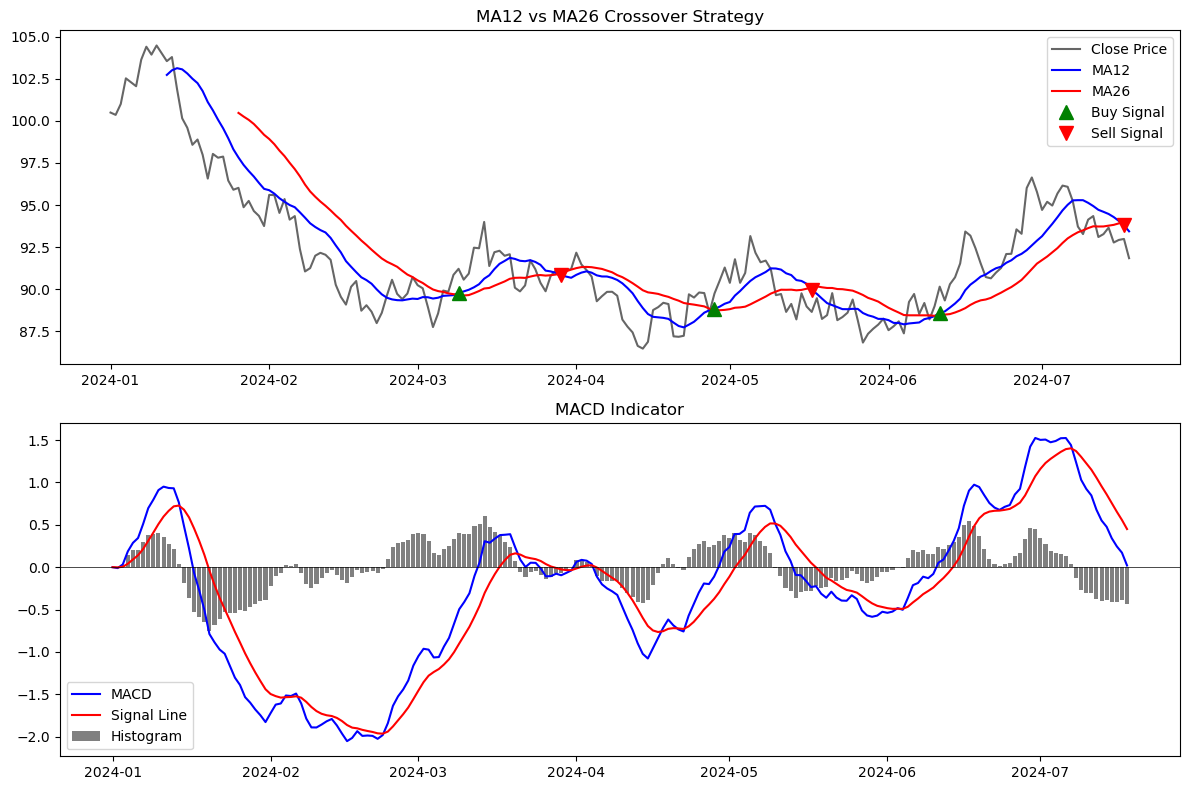

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --- Generate synthetic price data ---
np.random.seed(42)
dates = pd.date_range(start="2024-01-01", periods=200)
prices = np.cumsum(np.random.randn(200)) + 100
df = pd.DataFrame({"Close": prices}, index=dates)

# --- Moving Averages ---
df["MA12"] = df["Close"].rolling(window=12).mean()
df["MA26"] = df["Close"].rolling(window=26).mean()

# --- MA Crossover Signals ---
df["Signal"] = np.where(df["MA12"] > df["MA26"], 1, -1)
df["Crossover"] = df["Signal"].diff()

# --- MACD Calculation ---
df["EMA12"] = df["Close"].ewm(span=12, adjust=False).mean()
df["EMA26"] = df["Close"].ewm(span=26, adjust=False).mean()
df["MACD"] = df["EMA12"] - df["EMA26"]
df["SignalLine"] = df["MACD"].ewm(span=9, adjust=False).mean()
df["Histogram"] = df["MACD"] - df["SignalLine"]

# --- Plot ---
plt.figure(figsize=(12,8))

# Price + MA Crossovers
plt.subplot(2,1,1)
plt.plot(df.index, df["Close"], label="Close Price", color="black", alpha=0.6)
plt.plot(df.index, df["MA12"], label="MA12", color="blue")
plt.plot(df.index, df["MA26"], label="MA26", color="red")
plt.plot(df[df["Crossover"] == 2].index, df["MA12"][df["Crossover"] == 2],
         "^", markersize=10, color="green", label="Buy Signal")
plt.plot(df[df["Crossover"] == -2].index, df["MA12"][df["Crossover"] == -2],
         "v", markersize=10, color="red", label="Sell Signal")
plt.title("MA12 vs MA26 Crossover Strategy")
plt.legend()

# MACD Plot
plt.subplot(2,1,2)
plt.plot(df.index, df["MACD"], label="MACD", color="blue")
plt.plot(df.index, df["SignalLine"], label="Signal Line", color="red")
plt.bar(df.index, df["Histogram"], label="Histogram", color="gray")
plt.axhline(0, color="black", linewidth=0.5)
plt.title("MACD Indicator")
plt.legend()

plt.tight_layout()
plt.show()

**MACD (bottom panel)**

- EMA12 & EMA26: Short-term (red) and long-term exponential moving averages.
- MACD Line: Difference between EMA12 and EMA26.
- Signal Line: 9-day EMA of the MACD line.
- Histogram: Difference between MACD and Signal line (shows momentum strength).

### 📉 Example Chart

Comparing the side by side shows that MACD often confirms or filters crossover signals, reducing false positives in choppy markets.

---

## MACD (Moving Average Convergence Divergence)

The Moving Average Crossover (MACD) is a momentum indicator in trading that compares short-term and long-term moving averages to identify trend direction, strength, and potential reversals.

The MA Crossover strategy is a simpler cousin of MACD. Both compare short-term and long-term averages, but the latter (MACD) adds a signal line and histogram to highlight momentum.

---

### 🔑 Key Components

- **MACD Line** = 12-day EMA − 26-day EMA  
- **Signal Line** = 9-day EMA of the MACD line  
- **Histogram** = Difference between MACD line and Signal line  

---

### 📊 How Traders Use MACD

- **Crossovers**  
  - MACD line crosses above Signal line → **Bullish signal** (buy)  
  - MACD line crosses below Signal line → **Bearish signal** (sell)  

- **Zero Line Cross**  
  - MACD above zero → Uptrend momentum  
  - MACD below zero → Downtrend momentum  

- **Divergences**  
  - Price rising but MACD falling → Possible bearish reversal  
  - Price falling but MACD rising → Possible bullish reversal  

---

### ✅ Advantages

- Easy to interpret for beginners  
- Combines **trend-following** and **momentum** analysis
- Works across stocks, forex, crypto, and commodities  

---

### ⚠️ Limitations

- Can also give **false signals** in sideways/choppy markets  
- Best used with other indicators (like RSI or volume) for confirmation

---

👉 In essence, the MA crossover strategy is a **simplified cousin** of MACD. Both rely on comparing short-term and long-term averages, but MACD adds extra layers (signal line + histogram) to visualize momentum more clearly.

## VWAP